# Neural Networks in scikit-learn

This notebook focuses on instead of the working of a nn in itself:

1. Understanding neural network components in scikit-learn
2. Parameters vs fitted attributes
3. Optimization methods (Adam, SGD, LBFGS)
4. Practical usage and interpretation

Goal:
Understand how neural networks are implemented and controlled in practice.

In [1]:
# DATA PREPARATION, yes we need to do this all the time

import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

data = load_iris()

X = data.data
y = data.target

# Important: scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [3]:

from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=500
)

model.fit(X_train, y_train)


c:\Users\muella\Desktop\Python\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None


## Parameters vs Fitted Attributes

### Parameters (you set them)

Defined before training:

- hidden_layer_sizes --> architecture
- activation --> activation function
- solver --> optimization method
- learning_rate_init --> step size
- max_iter --> training iterations

These control how the model learns.

### Fitted Attributes (learned by the model)

After training:

- coefs_ --> weight matrices
- intercepts_ --> biases
- loss_curve_ --> error over time

These represent what the model learned from data.


### Key Insight

Parameters = instructions  
Fitted attributes = learned knowledge


In [4]:
# INSPECT FITTED MODEL

print("Number of layers:", len(model.coefs_))
print("Weights shape:", [w.shape for w in model.coefs_])

print("First layer weights:")
print(model.coefs_[0])

Number of layers: 2
Weights shape: [(4, 50), (50, 3)]
First layer weights:
[[-2.26215676e-01 -1.74163993e-01 -3.80903945e-01  1.68675546e-01
  -7.89919884e-03 -1.23192419e-01 -6.52779074e-02 -8.82889448e-02
   4.30618258e-02  2.23709288e-01  3.09665109e-01  4.61982397e-01
  -2.83059195e-02  1.74277426e-02  5.02261047e-02 -8.50991462e-02
  -3.54722261e-01  2.87906743e-01  3.19732514e-02 -5.84011445e-02
  -6.89548240e-03 -3.06732700e-01  2.90784975e-01 -2.28823470e-01
  -4.29123697e-01  2.56254484e-01 -1.21245883e-01 -6.29031839e-04
   3.15296670e-01  7.39796844e-02  3.61347374e-01  3.30439451e-02
  -3.70195459e-01 -1.79380636e-01 -1.33547151e-01  2.17845391e-01
  -7.60596829e-02  2.92934285e-01 -3.97231086e-01 -2.10833300e-01
   1.18178470e-01 -4.99349867e-01 -2.16328745e-01  2.79742493e-01
  -5.80277591e-03  3.19242897e-01  2.80126226e-02 -3.70193597e-01
  -3.94492692e-01  3.04374131e-01]
 [-2.13866344e-02  3.36802801e-01  4.32452277e-01 -4.33618861e-01
  -7.78114381e-02 -8.08584126e-0

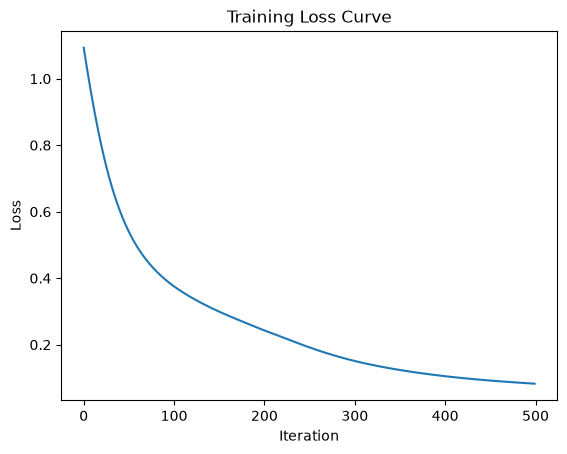

In [5]:
#Loss Curve
import matplotlib.pyplot as plt

plt.plot(model.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

## Optimization Methods in Neural Networks

 1. Adam (default)

- adaptive learning rates
- combines momentum + scaling

 stable  
 works well in most cases, we love adam  


### 2. SGD (Stochastic Gradient Descent)

- simple gradient updates
- requires manual tuning

flexible  
sensitive to learning rate  


### 3. LBFGS

- second-order optimization
- no mini-batches

works well for small datasets  
not scalable  


### Key Insight

Different optimizers = different ways of updating weights

In [6]:
# COMPARING OPTIMIZERS

solvers = ["adam", "sgd", "lbfgs"]

for solver in solvers:
    
    model = MLPClassifier(
        hidden_layer_sizes=(50,),
        solver=solver,
        max_iter=500,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    print(f"{solver}: final loss = {model.loss_:.4f}")


adam: final loss = 0.0787
sgd: final loss = 0.3152
lbfgs: final loss = 0.0004


c:\Users\muella\Desktop\Python\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\muella\Desktop\Python\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## Learning Rate

Controls how big each update step is:

- too small --> slow learning  
- too large --> unstable training  


### Analogy

Walking downhill:

- small steps --> slow  
- large steps --> might fall  


### Key Insight

Learning rate strongly affects convergence behavior

In [7]:
# LEARNING RATE EXPERIMENT

rates = [0.001, 0.01, 0.1]

for lr in rates:
    
    model = MLPClassifier(
        solver="sgd",
        learning_rate_init=lr,
        hidden_layer_sizes=(50,),
        max_iter=500,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    print(f"LR {lr}: final loss = {model.loss_:.4f}")

LR 0.001: final loss = 0.3152
LR 0.01: final loss = 0.0753
LR 0.1: final loss = 0.0495


c:\Users\muella\Desktop\Python\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## Evaluation Metrics for Classification


### 1. Why Accuracy is Not Enough

Accuracy measures:

    correct predictions / total predictions

Problem:
- ignores class imbalance  
- does not show types of errors  


### 2. Precision

Measures:

    When the model predicts a class, how often is it correct?

High precision = few false positives


### 3. Recall

Measures:

    How many true samples did we correctly find?

High recall = few false negatives


### 4. F1 Score

Balances precision and recall:

    F1 = harmonic mean of precision and recall

Useful when both types of errors matter.


### 5. Log Loss (Cross-Entropy)

Measures quality of predicted probabilities:

- correct + confident → low loss  
- wrong + confident → very high loss  


### 6. Confusion Matrix

Shows:

    actual vs predicted values

Helps identify:

- which classes are confused  
- types of errors  


### Key Insight

Evaluation metrics answer:

    How good is this model for my specific problem?

Different metrics highlight different weaknesses.

In [8]:
# MODEL EVALUATION (aka. we learn about more metrics than accuracy now)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    confusion_matrix,
    classification_report
)

# Predictions
preds = model.predict(X_test)

# Some models also give probabilities
if hasattr(model, "predict_proba"):
    probs = model.predict_proba(X_test)
else:
    probs = None

# BASIC METRICS

accuracy = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds, average="weighted")
recall = recall_score(y_test, preds, average="weighted")
f1 = f1_score(y_test, preds, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# PROBABILITY-BASED METRIC

if probs is not None:
    loss = log_loss(y_test, probs)
    print("Log Loss:", loss)

# CONFUSION MATRIX

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, preds))

# FULL CLASSIFICATION REPORT

print("\nClassification Report:")
print(classification_report(y_test, preds))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Log Loss: 0.029522397370484618

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Final Understanding

You now understand:

### Neural Networks in scikit-learn consist of:

- Parameters (architecture, optimization choices)
- Optimization process (gradient-based)
- Learned weights (coefs_)


### Training process:

1. Initialize weights  
2. Predict  
3. Compute loss  
4. Update weights  

### Evaluation process
- there are multiple metrics we can use to evaluate to analyse our models perfomance
- each of them is used for different use cases

### Key Concept

Neural networks are NOT magic:

They are:

    parameterized functions optimized using gradients


## ROC Curve and Precision-Recall Curve

### 1. Why We Need These

Accuracy alone is not sufficient.

We need to understand:

- how the model behaves under different thresholds  
- how it balances false positives and false negatives  


## ROC Curve (Receiver Operating Characteristic)

### Idea

Plot:

    True Positive Rate vs False Positive Rate


### Interpretation

- good model --> curve close to top-left  
- random model --> diagonal line  


### AUC (Area Under Curve)

Measures overall performance:

- 1.0 --> perfect  
- 0.5 --> random  

### Intuition

ROC answers:

    How well can the model separate classes?


## Precision-Recall Curve

### Idea

Plot:

    Precision vs Recall


### Interpretation

- shows tradeoff:
    high recall --> more positives found  
    high precision --> fewer false positives  


### When to Use

Better than ROC when:

- classes are imbalanced  
- false positives matter  


## Key Difference

ROC:
    focuses on ranking performance

PR:
    focuses on prediction quality for positive class

## Important Insight

Both curves depend on:

    probability outputs

This is why:

    predict_proba() is critical

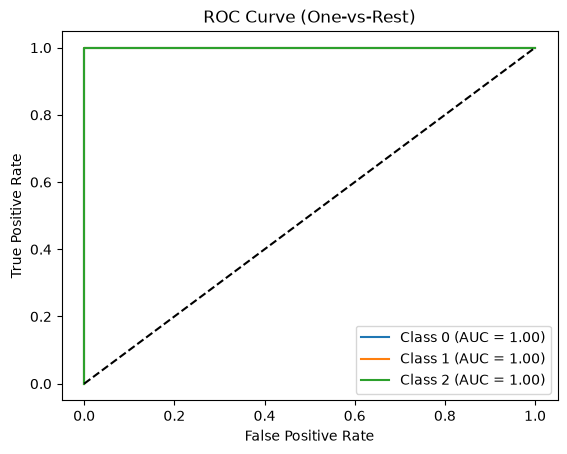

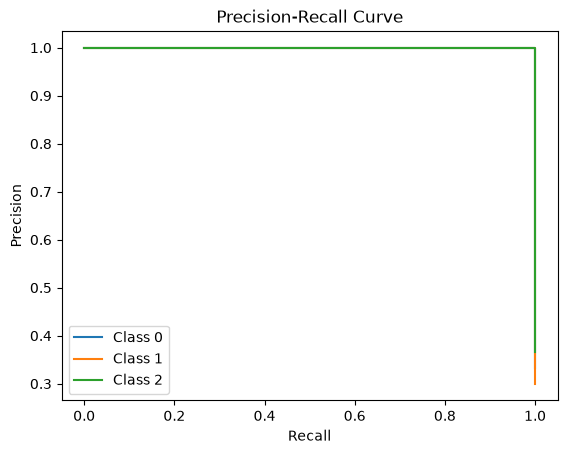

In [ ]:
# ROC CURVE + PRECISION-RECALL CURVE

import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import label_binarize

# STEP 1  GET PROBABILITIES again

# Neural networks give probabilities 
y_probs = model.predict_proba(X_test)

# STEP 2  BINARIZE TARGET (multiclass → one-vs-rest)

# Iris has 3 classes --> we convert to binary for each class
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

n_classes = y_test_bin.shape[1]

# ROC CURVE

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend()
plt.show()

# PRECISION-RECALL CURVE

plt.figure()

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i], y_probs[:, i]
    )
    
    plt.plot(recall, precision, label=f"Class {i}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()
